In [1]:
import sys
sys.path.insert(0, "/global/homes/q/qhang/desc/gcr-catalogs/")


import GCRCatalogs
from GCR import GCRQuery

import pickle
import numpy as np

import pandas as pd

In [2]:
import pylab as pl

In [3]:
## check version
print('GCRCatalogs =', GCRCatalogs.__version__, '|' ,'GCR =', GCRCatalogs.GCR.__version__)

GCRCatalogs = 1.8.0 | GCR = 0.9.2


In [3]:
print('\n'.join(sorted(GCRCatalogs.get_available_catalogs())))

buzzard
buzzard_high-res
cosmoDC2_v1.1.4_image
cosmoDC2_v1.1.4_redmagic_v0.8.1_highdens
cosmoDC2_v1.1.4_redmagic_v0.8.1_highlum
cosmoDC2_v1.1.4_redmapper_v0.8.1
cosmoDC2_v1.1.4_small
cosmoDC2_v1.1.4_wazp_v1.0_flexzboost_v1
cosmoDC2_v1.1.4_wazp_v1.0_truez
dc2_object_run1.2i
dc2_object_run1.2i_all_columns
dc2_object_run1.2i_tract4850
dc2_object_run1.2i_with_photoz
dc2_object_run1.2p
dc2_object_run1.2p_all_columns
dc2_object_run1.2p_tract4850
dc2_object_run2.2i_dr2_wfd
dc2_object_run2.2i_dr2_wfd_with_addons
dc2_object_run2.2i_dr3a
dc2_object_run2.2i_dr3a_with_metacal
dc2_object_run2.2i_dr3a_with_photoz
dc2_object_run2.2i_dr6
dc2_object_run2.2i_dr6_v2_with_addons_v2
dc2_object_run2.2i_dr6_with_addons
dc2_redmagic_run2.2i_dr6_wfd_v0.8.1_highdens
dc2_redmagic_run2.2i_dr6_wfd_v0.8.1_highlum
dc2_redmapper_run2.2i_dr6_wfd_v0.8.1
dc2_run2.2i_truth_galaxy_summary
dc2_run2.2i_truth_merged_summary
dc2_run2.2i_truth_sn_summary
dc2_run2.2i_truth_sn_variability
dc2_run2.2i_truth_star_summary
dc2_run2.

In [4]:
print('\n'.join(sorted(c for c in GCRCatalogs.get_available_catalogs(include_default_only=False) if c.startswith('roman'))))

roman_rubin_2023_v1.1.2_elais
roman_rubin_2023_v1.1.3_elais


In [3]:
def dump_load(filename):
    with open(filename,'rb') as fin:
        stuff=pickle.load(fin)
        #self.impute = json.load(fin)
    #print('loaded impute ditionary:',filename)
    return stuff

def dump_save(stuff,filename):
    '''This saves the dictionary and loads it from appropriate files'''
    with open(filename,'wb') as fout:
        pickle.dump(stuff,fout,pickle.HIGHEST_PROTOCOL)
        #json.dump(self.impute, fout, sort_keys=True, indent=3)
    #print('written impute ditionary:',filename)
    return 0

# SkySim5000 subsample

In [3]:
#catalog = GCRCatalogs.load_catalog('skysim5000_v1.1.1_parquet')

In [4]:
catalog = GCRCatalogs.load_catalog('skysim5000_v1.1.1_small')

In [6]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('size'))

['size_bulge_true',
 'size_disk_true',
 'size_minor_bulge_true',
 'size_minor_disk_true',
 'size_minor_true',
 'size_true']

In [7]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('redshift'))

['redshift', 'redshift_true']

In [7]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('ellipticity'))

['ellipticity_1_bulge_true',
 'ellipticity_1_disk_true',
 'ellipticity_1_true',
 'ellipticity_2_bulge_true',
 'ellipticity_2_disk_true',
 'ellipticity_2_true',
 'ellipticity_bulge_true',
 'ellipticity_disk_true',
 'ellipticity_true']

In [8]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('mag'))

['mag_g',
 'mag_g_lsst',
 'mag_g_lsst_no_host_extinction',
 'mag_g_sdss',
 'mag_g_sdss_no_host_extinction',
 'mag_i',
 'mag_i_lsst',
 'mag_i_lsst_no_host_extinction',
 'mag_i_sdss',
 'mag_i_sdss_no_host_extinction',
 'mag_r',
 'mag_r_lsst',
 'mag_r_lsst_no_host_extinction',
 'mag_r_sdss',
 'mag_r_sdss_no_host_extinction',
 'mag_true_g',
 'mag_true_g_lsst',
 'mag_true_g_lsst_no_host_extinction',
 'mag_true_g_sdss',
 'mag_true_g_sdss_no_host_extinction',
 'mag_true_i',
 'mag_true_i_lsst',
 'mag_true_i_lsst_no_host_extinction',
 'mag_true_i_sdss',
 'mag_true_i_sdss_no_host_extinction',
 'mag_true_r',
 'mag_true_r_lsst',
 'mag_true_r_lsst_no_host_extinction',
 'mag_true_r_sdss',
 'mag_true_r_sdss_no_host_extinction',
 'mag_true_u',
 'mag_true_u_lsst',
 'mag_true_u_lsst_no_host_extinction',
 'mag_true_u_sdss',
 'mag_true_u_sdss_no_host_extinction',
 'mag_true_y',
 'mag_true_y_lsst',
 'mag_true_y_lsst_no_host_extinction',
 'mag_true_z',
 'mag_true_z_lsst',
 'mag_true_z_lsst_no_host_extinctio

In [5]:
from GCR import GCRQuery

data = catalog.get_quantities(['mag_u_lsst','mag_g_lsst','mag_r_lsst',
                              'mag_i_lsst','mag_z_lsst','mag_y_lsst',
                              'redshift', 'size_true', 'size_minor_true'],
                             filters=["mag_i_lsst < 26.5"])
# we can add a filter in i-band
#data_subset = coord_cut.filter(data)
# take a subset sample of 10^6 objects:
print(len(data["redshift"]))

24969446


In [6]:
index = np.random.choice(np.arange(len(data["redshift"])), size=int(1e6), 
                                  replace=False)

In [15]:
index

array([88121183, 22114078, 89624651, ..., 75986851, 28483470, 84683708])

In [7]:
name_dict={
    "mag_u_lsst": "u",
    "mag_g_lsst": "g",
    "mag_r_lsst": "r",
    "mag_i_lsst": "i",
    "mag_z_lsst": "z",
    "mag_y_lsst": "y",
    "redshift": "redshift",
    "size_true": "major",
    "size_minor_true":"minor",
}

data_subset={}
for key in data.keys():
    data_subset[name_dict[key]]=data[key][index]

In [8]:
data_subset_pd=pd.DataFrame(data=data_subset)

In [25]:
data_subset_pd

,y,z,r,redshift,major,i,u,g,minor
0,28.388647,28.589821,28.767378,2.607192,0.106921,28.618017,31.605962,29.389801,0.094869
1,26.463826,26.990947,27.046968,1.434276,0.075093,27.023078,26.928384,26.958251,0.064417
2,28.406794,28.767331,29.229935,2.206357,0.061196,29.089512,32.250041,29.770325,0.054226
3,22.651950,22.760852,22.687189,1.257895,0.253788,22.865074,22.281009,22.419135,0.249414
4,24.220813,24.724241,25.118825,1.536618,0.145518,24.894508,25.277984,25.172023,0.084460
...,...,...,...,...,...,...,...,...,...
999995,26.188601,26.915585,28.859126,1.362142,0.396887,27.543555,32.578612,30.053500,0.229863
999996,25.460122,25.634648,26.091649,1.746977,0.111287,25.861600,26.170136,25.986476,0.097731
999997,29.652138,29.803092,29.928387,2.679545,0.050762,29.817910,32.506087,30.487309,0.050297
999998,27.218774,27.854413,28.687364,1.347892,0.064763,28.307464,29.271909,28.976886,0.039368


In [9]:
# turn this into pd

# save data_subset
savedir="/pscratch/sd/q/qhang/skysim5000/nonuniform-maf/"
dump_save(data_subset_pd, savedir+"skysim5000_v1.1.1_small-subset.pkl")

0

Load and check the catalogue

In [11]:
savedir="/pscratch/sd/q/qhang/skysim5000/nonuniform-maf/"
fname=savedir+"skysim5000_v1.1.1_small-subset.pkl"
cat=dump_load(fname)

Text(0.5, 0, 'i mag')

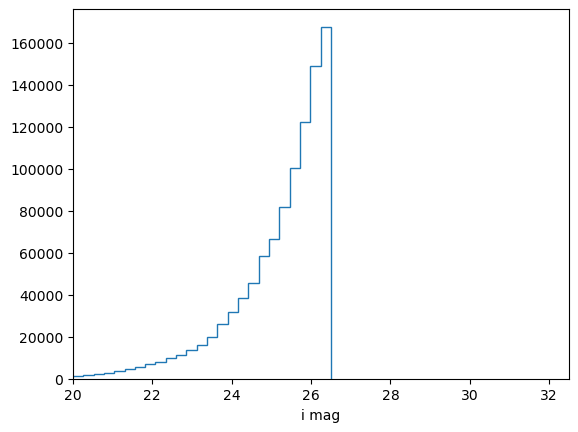

In [12]:
# look at i-band distribution:

cc = pl.hist(cat['i'],bins=50,histtype='step')
pl.xlim([20,32.5])
pl.xlabel("i mag")

# Roman-Rubin subsample

In [4]:
catalog = GCRCatalogs.load_catalog('roman_rubin_2023_v1.1.3_elais')

In [7]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('size'))

['size_bulge_true', 'size_disk_true']

In [8]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('ellipticity'))

['ellipticity_bulge_true', 'ellipticity_disk_true', 'ellipticity_true']

In [10]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('minor'))

[]

In [11]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('mag_i'))

['mag_i', 'mag_i_lsst', 'mag_i_sdss']

In [12]:
sorted(q for q in catalog.list_all_quantities() if q.startswith('redshift'))

['redshift', 'redshift_true']

In [5]:
sorted(q for q in catalog.list_all_quantities() if ('bulge' in q))

['bulge_to_total_ratio', 'ellipticity_bulge_true', 'size_bulge_true']

In [6]:
sorted(q for q in catalog.list_all_quantities() if ('disk' in q))

['ellipticity_disk_true', 'size_disk_true']

In [13]:
# test
from GCR import GCRQuery
data = catalog.get_quantities(['mag_i_lsst','redshift'],
                             filters=["mag_i_lsst < 26.5"])
# we can add a filter in i-band
print(len(data["redshift"]))

29992664


Text(0.5, 0, 'i mag')

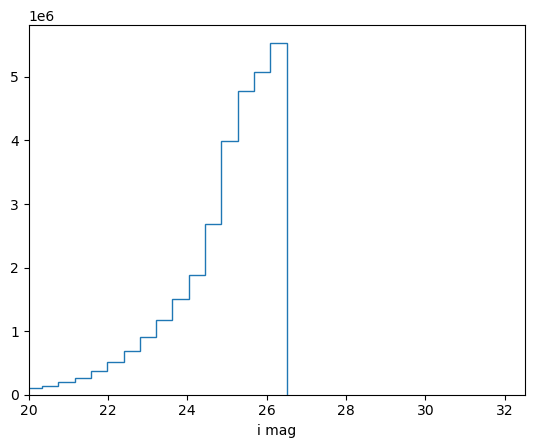

In [18]:
cc=pl.hist(data['mag_i_lsst'],bins=50, histtype='step')
pl.xlim([20,32.5])
pl.xlabel("i mag")

Text(0.5, 0, 'redshift')

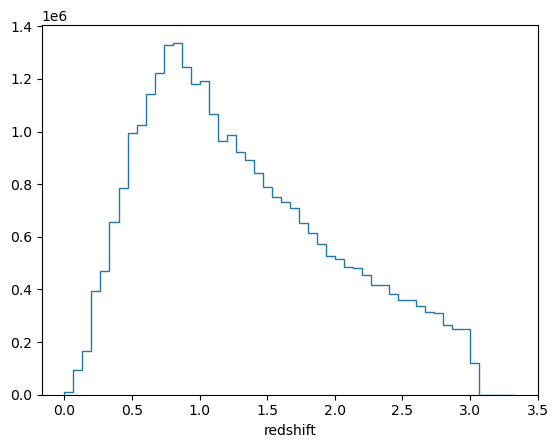

In [19]:
cc=pl.hist(data['redshift'],bins=50, histtype='step')
#pl.xlim([20,32.5])
pl.xlabel("redshift")

In [7]:
from GCR import GCRQuery

data = catalog.get_quantities(['mag_u_lsst','mag_g_lsst','mag_r_lsst',
                              'mag_i_lsst','mag_z_lsst','mag_y_lsst',
                              'redshift', 'size_bulge_true', 'size_disk_true',
                              'bulge_to_total_ratio', 'ellipticity_true'],
                             filters=["mag_i_lsst < 26.5"])
# we can add a filter in i-band
#data_subujmnset = coord_cut.filter(data)
# take a subset sample of 10^6 objects:
print(len(data["redshift"]))

29992664


In [8]:
index = np.random.choice(np.arange(len(data["redshift"])), size=int(1e6), 
                                  replace=False)

In [9]:
data_subset={}
for key in data.keys():
    data_subset[key]=data[key][index]

In [12]:
def get_semi_major_minor(ellipticity, size, scale=1):

    q = (1 - ellipticity)/(1 + ellipticity)
    
    # ab=size**2
    # b/a=q
    
    bi =np.sqrt(size**2*q)
    ai = size**2/bi
    
    #ai = size
    #bi = ai*q

    ai = ai*scale
    bi = bi*scale
    
    return ai, bi

In [13]:
# now compute major, minor axis:
rr=data_subset["bulge_to_total_ratio"]
size=data_subset["size_bulge_true"]*rr+data_subset["size_disk_true"]*(1-rr)

maj, mino=get_semi_major_minor(data_subset["ellipticity_true"], size, scale=1)

In [14]:
maj[:5], mino[:5]

(array([0.06865557, 0.35215685, 0.29219169, 0.0606919 , 0.24218646]),
 array([0.03472663, 0.18553834, 0.19657682, 0.02598075, 0.16020795]))

In [18]:
name_dict={
    "mag_u_lsst": "u",
    "mag_g_lsst": "g",
    "mag_r_lsst": "r",
    "mag_i_lsst": "i",
    "mag_z_lsst": "z",
    "mag_y_lsst": "y",
    "redshift": "redshift",
}

data_out={}

for key in name_dict.keys():
    data_out[name_dict[key]]=data_subset[key]

data_out["major"]=maj
data_out["minor"]=mino
    
print(data_out.keys())
data_out_pd=pd.DataFrame(data=data_out)

# turn this into pd

# save data_subset
savedir="/pscratch/sd/q/qhang/roman-rubin-sims/nonuniform-maf/"
dump_save(data_out_pd, savedir+"roman_rubin_2023_v1.1.3_elais-subset.pkl")

dict_keys(['u', 'g', 'r', 'i', 'z', 'y', 'redshift', 'major', 'minor'])


0

Text(0, 0.5, 'g-r')

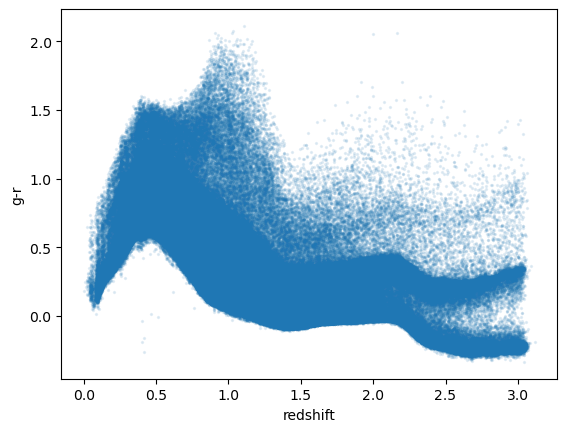

In [24]:
# check the g-r vs redshift plot:
pl.scatter(data_out["redshift"], data_out["g"]-data_out["r"], s=2,alpha=0.1)
pl.xlabel("redshift")
pl.ylabel("g-r")

In [27]:
# load the roman-rubin catalogue:
savedir="/pscratch/sd/q/qhang/roman-rubin-sims/nonuniform-maf/"
fname=savedir+"roman_rubin_2023_v1.1.3_elais-subset.pkl"
data_out=dump_load(fname)

In [4]:
# load the skysim500 catalogue:
savedir="/pscratch/sd/q/qhang/skysim5000/nonuniform-maf/"
fname=savedir+"skysim5000_v1.1.1_small-subset.pkl"
cat=dump_load(fname)

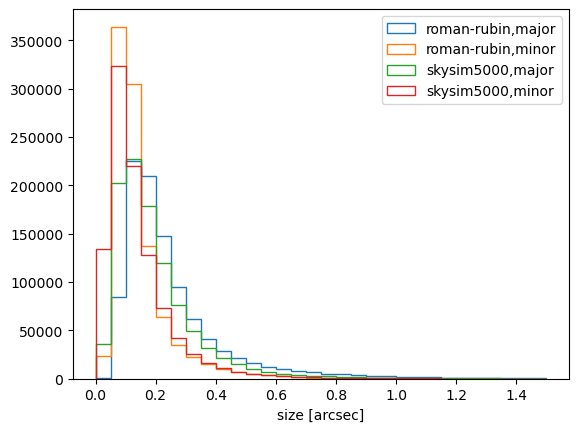

In [28]:
# so I could check major, minor axis in diff catalogues see if clear offsets
cc=pl.hist(data_out["major"],histtype='step', range=[0,1.5],bins=30, label="roman-rubin,major")
cc=pl.hist(data_out["minor"],histtype='step', range=[0,1.5],bins=30, label="roman-rubin,minor")
#pl.text("roman-rubin")
#pl.xlabel("size [arcsec]")
#pl.legend()

cc=pl.hist(cat["major"],histtype='step', range=[0,1.5],bins=30, label="skysim5000,major")
cc=pl.hist(cat["minor"],histtype='step', range=[0,1.5],bins=30, label="skysim5000,minor")
#pl.title("skysim5000")
pl.xlabel("size [arcsec]")
pl.legend()